ЭТАП 1: Загрузка данных
Файл cup_it_example_src_B.csv не найден в текущей директории.
Текущая рабочая директория: /Users/mariaroslyakova/PyCharmMiscProject

Ищем файл в поддиректориях...
Найден файл: ./changellenge_case_MTS/cup_it_example_src_B.csv
✓ Загружено записей: 161,076

ЭТАП 2: Расчет высоты зданий
✓ Рассчитано высот по формуле stairs * avg_floor_height: 0
✓ Всего записей с высотой: 161,010
✓ Записей без высоты (будут удалены): 66

ЭТАП 3: Удаление объектов без высоты
✓ Удалено объектов без высоты: 66
✓ Осталось объектов: 161,010

ЭТАП 4: Фильтрация по высоте (альтернативный метод)
Статистика высот до фильтрации:
  - Минимальная высота: 2.00 м
  - Максимальная высота: 462.00 м
  - Средняя высота: 14.68 м
  - Медианная высота: 6.60 м
  - 99-й перцентиль: 78.00 м

Альтернативные методы расчета верхней границы высоты:
  - Метод 1 (99-й перцентиль + 20, но не более 200): 98.00 м
  - Метод 2 (Медиана + 3*σ): 52.10 м
  - Метод 3 (95-й перцентиль * 1.2): 54.00 м

Выбранные границы фил

  Обработка полигонов: 82726it [00:06, 12699.29it/s]                           


✓ Граф построен. Количество ребер: 46,977

ЭТАП 13: Анализ графа

Основные характеристики:
  - Количество вершин: 82,626
  - Количество ребер: 46,977

  Компоненты связности:
  - Количество компонент: 41,230
  - Размер компонент:
    * Минимальный: 1
    * Максимальный: 68
    * Медианный: 1
    * Средний: 2.00

  Степени вершин:
  - Минимальная степень: 0
  - Максимальная степень: 28
  - Средняя степень: 1.14
  - Медианная степень: 1

  Распределение степеней (топ-10):
    * Степень 0: 30,628 вершин (37.07%)
    * Степень 1: 30,942 вершин (37.45%)
    * Степень 2: 10,459 вершин (12.66%)
    * Степень 3: 5,412 вершин (6.55%)
    * Степень 4: 2,712 вершин (3.28%)
    * Степень 5: 1,209 вершин (1.46%)
    * Степень 6: 582 вершин (0.70%)
    * Степень 7: 357 вершин (0.43%)
    * Степень 8: 139 вершин (0.17%)
    * Степень 9: 97 вершин (0.12%)
    * Степень 10: 45 вершин (0.05%)

ЭТАП 14: Визуализация результатов

  Визуализация крупнейшей компоненты (68 вершин)...


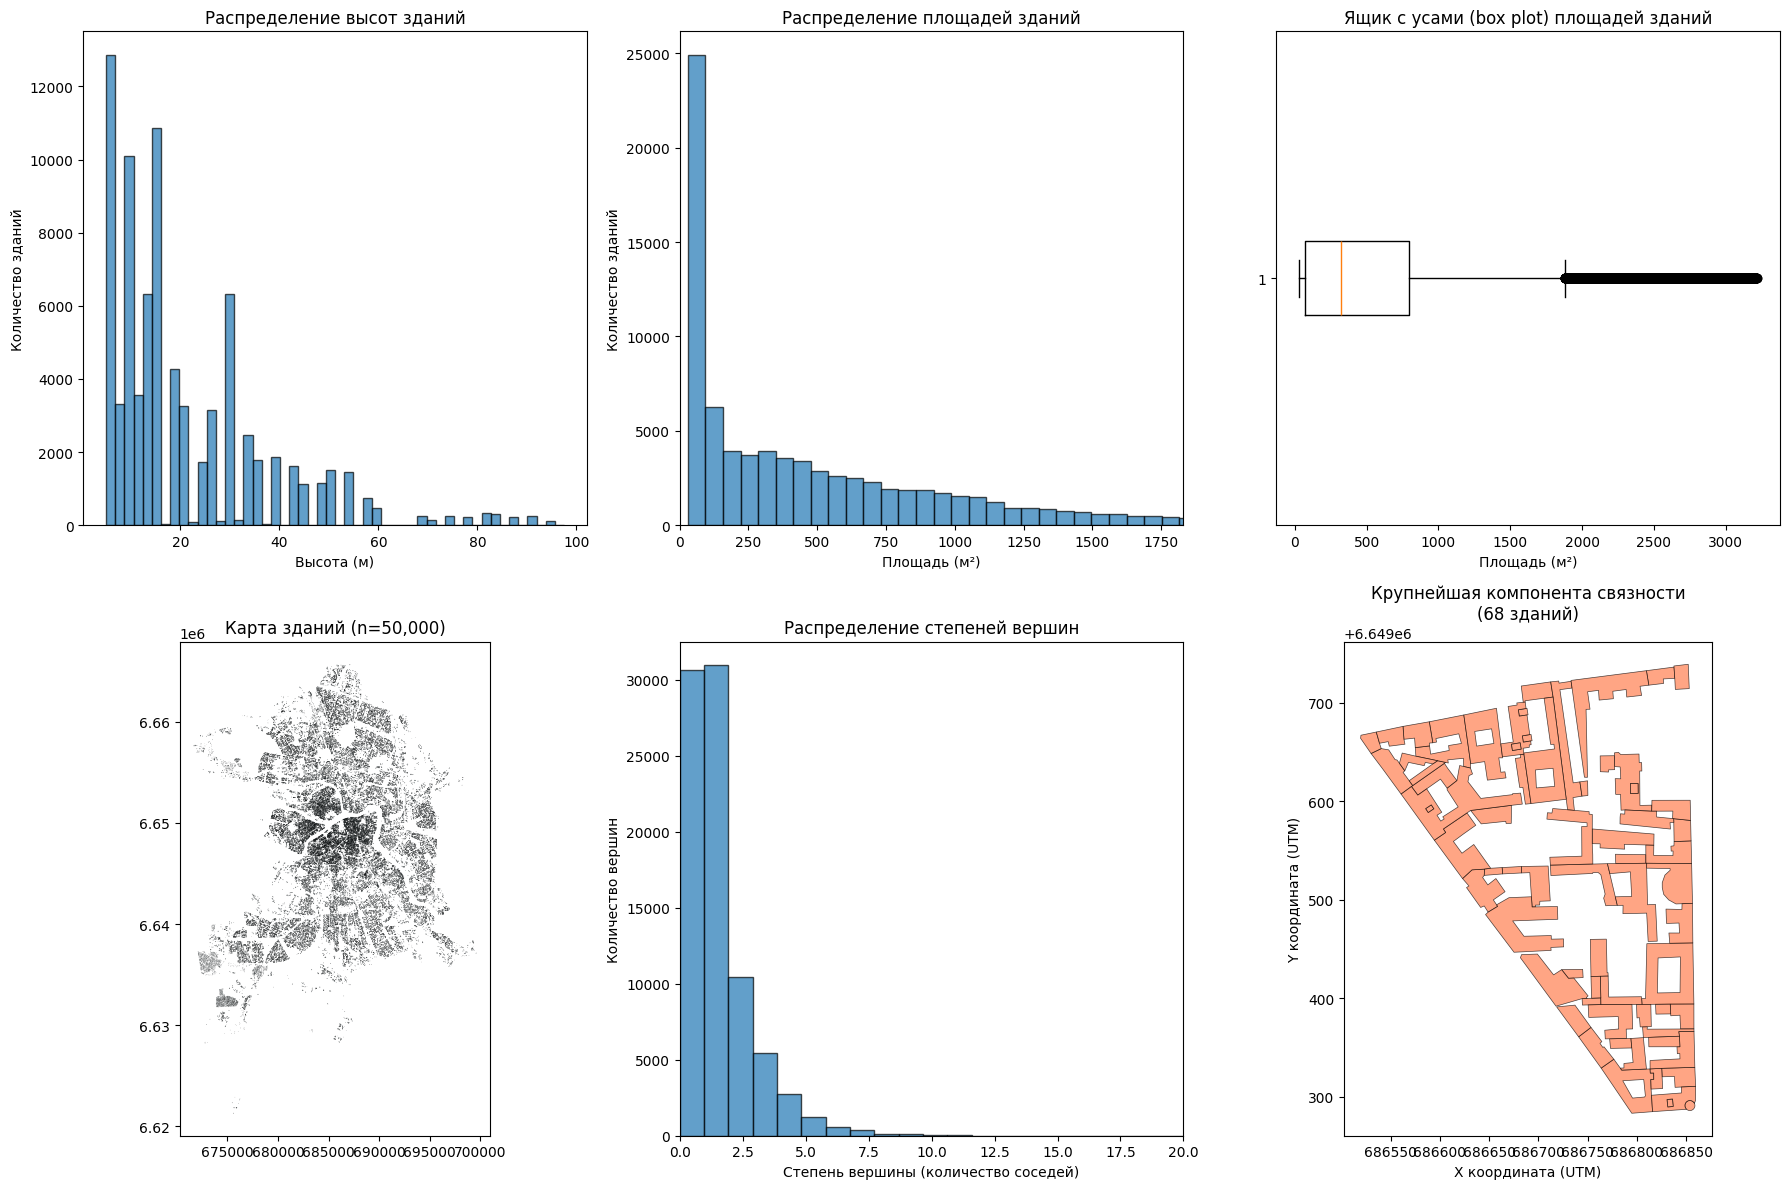


ИТОГОВАЯ СТАТИСТИКА ОБРАБОТКИ

Начальное количество записей: 161,076
Количество объектов после всех этапов очистки: 82,626
Удалено объектов (в процентах): 48.70%

Количество вершин в графе: 82,626
Количество ребер в графе: 46,977

Компоненты связности:
  - Количество компонент: 41,230
  - Размер крупнейшей компоненты: 68
  - Количество изолированных зданий: 30,628

ОБРАБОТКА ЗАВЕРШЕНА


In [47]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
from shapely.validation import make_valid
from shapely.strtree import STRtree
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import warnings
from tqdm import tqdm
import time
import os

warnings.filterwarnings('ignore')

# ============================================================================
# ЭТАП 1: ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
# ============================================================================
print("=" * 80)
print("ЭТАП 1: Загрузка данных")
print("=" * 80)

# Указываем путь к файлу с данными
file_path = 'cup_it_example_src_B.csv'

# Проверяем существование файла, если нет - ищем в поддиректориях
if not os.path.exists(file_path):
    print(f"Файл {file_path} не найден в текущей директории.")
    print(f"Текущая рабочая директория: {os.getcwd()}")

    print("\nИщем файл в поддиректориях...")
    found_files = []
    for root, dirs, files in os.walk('.'):
        if 'cup_it_example_src_B.csv' in files:
            found_files.append(os.path.join(root, 'cup_it_example_src_B.csv'))

    if found_files:
        print(f"Найден файл: {found_files[0]}")
        file_path = found_files[0]
    else:
        print("Файл не найден.")
        raise FileNotFoundError("Файл cup_it_example_src_B.csv не найден")

# Загружаем CSV с указанием разделителя и кодировки
# low_memory=False гарантирует корректное определение типов данных
df = pd.read_csv(file_path, sep=',', encoding='utf-8', low_memory=False)
print(f"✓ Загружено записей: {len(df):,}")

# ============================================================================
# ЭТАП 2: РАСЧЕТ ВЫСОТЫ ЗДАНИЙ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 2: Расчет высоты зданий")
print("=" * 80)

# Определяем записи, где высота отсутствует или равна нулю/строковому нулю
# В исходных данных могут быть значения '0' или '0E-11' (научная нотация)
mask_missing_height = (df['height'].isna()) | (df['height'] == 0) | (df['height'] == '0') | (df['height'] == '0E-11')

# Преобразуем stairs и avg_floor_height в числовой формат (нечисловые значения становятся NaN)
df['stairs_numeric'] = pd.to_numeric(df['stairs'], errors='coerce')
df['avg_floor_height_numeric'] = pd.to_numeric(df['avg_floor_height'], errors='coerce')

# Рассчитываем высоту как произведение количества этажей на среднюю высоту этажа
# Вычисляем только для записей с отсутствующей высотой
calculated_height = df.loc[mask_missing_height, 'stairs_numeric'] * df.loc[mask_missing_height, 'avg_floor_height_numeric']
df.loc[mask_missing_height, 'height_calculated'] = calculated_height  # Сохраняем для информации
df.loc[mask_missing_height, 'height'] = calculated_height  # Заполняем исходное поле

# Преобразуем итоговую высоту в числовой формат для дальнейших вычислений
df['height_numeric'] = pd.to_numeric(df['height'], errors='coerce')

print(f"✓ Рассчитано высот по формуле stairs * avg_floor_height: {(~calculated_height.isna()).sum():,}")
print(f"✓ Всего записей с высотой: {df['height_numeric'].notna().sum():,}")
print(f"✓ Записей без высоты (будут удалены): {df['height_numeric'].isna().sum():,}")

# ============================================================================
# ЭТАП 3: УДАЛЕНИЕ ОБЪЕКТОВ С ПУСТОЙ ВЫСОТОЙ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 3: Удаление объектов без высоты")
print("=" * 80)

initial_count = len(df)
# Оставляем только записи с заполненной высотой
df = df[df['height_numeric'].notna()]
print(f"✓ Удалено объектов без высоты: {initial_count - len(df):,}")
print(f"✓ Осталось объектов: {len(df):,}")

# ============================================================================
# ЭТАП 4: ФИЛЬТРАЦИЯ ПО ВЫСОТЕ (УДАЛЕНИЕ ЭКСТРЕМАЛЬНЫХ ЗНАЧЕНИЙ)
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 4: Фильтрация по высоте (альтернативный метод)")
print("=" * 80)

# Выводим статистику для анализа
print(f"Статистика высот до фильтрации:")
print(f"  - Минимальная высота: {df['height_numeric'].min():.2f} м")
print(f"  - Максимальная высота: {df['height_numeric'].max():.2f} м")
print(f"  - Средняя высота: {df['height_numeric'].mean():.2f} м")
print(f"  - Медианная высота: {df['height_numeric'].median():.2f} м")
print(f"  - 99-й перцентиль: {df['height_numeric'].quantile(0.99):.2f} м")

# Альтернативный метод 1: Используем 99-й перцентиль + фиксированный запас
# Для Санкт-Петербурга максимальная высота жилых зданий ~200-250 м (небоскребы Лахта-центра)
# Поэтому разумный порог - 200 м
upper_height_bound_method1 = min(df['height_numeric'].quantile(0.99) + 20, 200.0)

# Альтернативный метод 2: Используем медиану + 3*стандартное отклонение (более мягкий порог)
std_height = df['height_numeric'].std()
median_height = df['height_numeric'].median()
upper_height_bound_method2 = median_height + 3 * std_height

# Альтернативный метод 3: Используем 95-й перцентиль + 20% запас
upper_height_bound_method3 = df['height_numeric'].quantile(0.95) * 1.2

print(f"\nАльтернативные методы расчета верхней границы высоты:")
print(f"  - Метод 1 (99-й перцентиль + 20, но не более 200): {upper_height_bound_method1:.2f} м")
print(f"  - Метод 2 (Медиана + 3*σ): {upper_height_bound_method2:.2f} м")
print(f"  - Метод 3 (95-й перцентиль * 1.2): {upper_height_bound_method3:.2f} м")

# Выбираем метод 1 как наиболее консервативный
upper_height_bound = upper_height_bound_method1
lower_height_bound = 5.0  # Физический минимум для зданий

print(f"\nВыбранные границы фильтрации по высоте:")
print(f"  - Нижняя граница (фиксированная): {lower_height_bound:.2f} м")
print(f"  - Верхняя граница (99-й перцентиль + 20, но не более 200): {upper_height_bound:.2f} м")

# Применяем фильтрацию
initial_count = len(df)
df = df[(df['height_numeric'] >= lower_height_bound) & (df['height_numeric'] <= upper_height_bound)]
print(f"\n✓ Удалено объектов с экстремальной высотой: {initial_count - len(df):,}")
print(f"✓ Осталось объектов: {len(df):,}")

# Дополнительная статистика после фильтрации
print(f"\nСтатистика высот после фильтрации:")
print(f"  - Минимальная высота: {df['height_numeric'].min():.2f} м")
print(f"  - Максимальная высота: {df['height_numeric'].max():.2f} м")
print(f"  - Средняя высота: {df['height_numeric'].mean():.2f} м")
print(f"  - Медианная высота: {df['height_numeric'].median():.2f} м")

# ============================================================================
# ЭТАП 5: ПРЕОБРАЗОВАНИЕ WKT В ГЕОМЕТРИЮ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 5: Преобразование WKT в геометрию")
print("=" * 80)

def safe_wkt_to_geometry(wkt_str):
    """
    Безопасное преобразование WKT строки в геометрию Shapely.
    Возвращает None в случае ошибки или пустой строки.
    """
    if not isinstance(wkt_str, str) or not wkt_str.strip():
        return None
    try:
        # Используем GeoSeries.from_wkt для преобразования
        geom = gpd.GeoSeries.from_wkt([wkt_str])[0]
        # Проверяем, что геометрия не пустая
        if geom is not None and not geom.is_empty:
            return geom
        return None
    except Exception:
        return None

# Применяем преобразование ко всем строкам
df['geometry'] = df['wkt'].apply(safe_wkt_to_geometry)
initial_count = len(df)
# Удаляем записи с некорректной геометрией
df = df.dropna(subset=['geometry'])
print(f"✓ Удалено записей с некорректной геометрией: {initial_count - len(df):,}")
print(f"✓ Осталось записей: {len(df):,}")

# ============================================================================
# ЭТАП 6: СОЗДАНИЕ GEODATAFRAME И ПРОЕЦИРОВАНИЕ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 6: Создание GeoDataFrame и проецирование")
print("=" * 80)

# Создаем GeoDataFrame с исходной системой координат WGS84 (EPSG:4326)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
print(f"✓ Создан GeoDataFrame с {len(gdf):,} объектами")

# Перепроецируем в метрическую систему UTM зона 35N (подходит для Санкт-Петербурга)
# Это необходимо для корректных вычислений площадей и расстояний в метрах
start_time = time.time()
gdf = gdf.to_crs('EPSG:32635')
print(f"✓ Перепроецировано в EPSG:32635 (UTM zone 35N) за {time.time() - start_time:.2f} сек")

# ============================================================================
# ЭТАП 7: РАСЧЕТ ПЛОЩАДЕЙ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 7: Расчет площадей")
print("=" * 80)

# Вычисляем площади всех объектов в квадратных метрах
gdf['area_m2'] = gdf.geometry.area
print(f"✓ Площади рассчитаны")
print(f"  - Минимальная площадь: {gdf['area_m2'].min():.2f} м²")
print(f"  - Максимальная площадь: {gdf['area_m2'].max():.2f} м²")
print(f"  - Средняя площадь: {gdf['area_m2'].mean():.2f} м²")
print(f"  - Медианная площадь: {gdf['area_m2'].median():.2f} м²")

# ============================================================================
# ЭТАП 8: ФИЛЬТРАЦИЯ ПО ПЛОЩАДИ (УДАЛЕНИЕ МАЛЕНЬКИХ ПОЛИГОНОВ)
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 8: Фильтрация по площади (удаление маленьких полигонов)")
print("=" * 80)

# Удаляем объекты с площадью менее 30 м² - это явные артефакты
min_area = 30.0
initial_count = len(gdf)
gdf = gdf[gdf['area_m2'] >= min_area]
print(f"✓ Удалено объектов с площадью < {min_area} м²: {initial_count - len(gdf):,}")
print(f"✓ Осталось объектов: {len(gdf):,}")

# ============================================================================
# ЭТАП 9: РЕМОНТ НЕВАЛИДНОЙ ГЕОМЕТРИИ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 9: Ремонт невалидной геометрии")
print("=" * 80)

# Проверяем геометрии на валидность (самопересечения, неправильная ориентация и т.д.)
invalid_mask = ~gdf.geometry.is_valid
invalid_count = invalid_mask.sum()
if invalid_count > 0:
    print(f"✓ Найдено невалидных геометрий: {invalid_count:,} ({invalid_count/len(gdf)*100:.2f}%)")

    def repair_geometry(geom):
        """
        Ремонт невалидной геометрии:
        1. Если геометрия валидна - возвращаем как есть
        2. Пытаемся исправить с помощью make_valid
        3. Если получили коллекцию, извлекаем только полигоны
        4. Удаляем объекты с нулевой площадью после ремонта
        """
        if geom is None or geom.is_empty:
            return None
        if geom.is_valid:
            return geom
        try:
            # make_valid - функция shapely для исправления геометрии
            repaired = make_valid(geom)
            # Если после исправления получили коллекцию, извлекаем полигоны
            if repaired.geom_type == 'GeometryCollection':
                polygons = [g for g in repaired.geoms if g.geom_type in ['Polygon', 'MultiPolygon']]
                if not polygons:
                    return None
                repaired = polygons[0] if len(polygons) == 1 else MultiPolygon(polygons)
            # Проверяем, что после ремонта объект имеет ненулевую площадь
            if repaired.area < 1e-6:
                return None
            return repaired
        except Exception:
            return None

    print("  Ремонт геометрий...")
    repaired_geoms = []
    # Используем tqdm для отображения прогресса
    for idx, row in tqdm(gdf[invalid_mask].iterrows(), total=invalid_count, desc="  Прогресс"):
        repaired = repair_geometry(row.geometry)
        repaired_geoms.append(repaired)

    # Обновляем геометрии
    gdf.loc[invalid_mask, 'geometry'] = repaired_geoms
    # Удаляем объекты, которые не удалось исправить
    gdf = gdf.dropna(subset=['geometry'])
    gdf = gdf[~gdf.geometry.is_empty]
    print(f"✓ Осталось объектов после ремонта: {len(gdf):,}")

    # Пересчитываем площади после ремонта
    gdf['area_m2'] = gdf.geometry.area
else:
    print("✓ Все геометрии валидны")

# ============================================================================
# ЭТАП 10: СТАТИСТИЧЕСКАЯ ФИЛЬТРАЦИЯ ВЫБРОСОВ ПО ПЛОЩАДИ (ВЕРХНЯЯ ГРАНИЦА)
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 10: Статистическая фильтрация выбросов по площади (верхняя граница)")
print("=" * 80)

# Используем IQR для выявления выбросов по площади (только верхняя граница)
Q1_area = gdf['area_m2'].quantile(0.25)
Q3_area = gdf['area_m2'].quantile(0.75)
IQR_area = Q3_area - Q1_area

# Верхняя граница: Q3 + 3*IQR (более мягкий порог для больших зданий)
upper_area_bound = Q3_area + 3 * IQR_area

print(f"Статистика площадей:")
print(f"  - Q1 (25-й перцентиль): {Q1_area:.2f} м²")
print(f"  - Медиана: {gdf['area_m2'].median():.2f} м²")
print(f"  - Q3 (75-й перцентиль): {Q3_area:.2f} м²")
print(f"  - IQR: {IQR_area:.2f} м²")
print(f"\nГраницы фильтрации:")
print(f"  - Нижняя граница (фиксированная): {min_area:.2f} м²")
print(f"  - Верхняя граница (IQR метод): {upper_area_bound:.2f} м²")

# Применяем фильтрацию (нижняя граница уже применена, удаляем только слишком большие)
initial_count = len(gdf)
gdf = gdf[gdf['area_m2'] <= upper_area_bound]
print(f"\n✓ Удалено объектов с аномально большой площадью: {initial_count - len(gdf):,}")
print(f"✓ Осталось объектов: {len(gdf):,}")

# ============================================================================
# ЭТАП 11: ОПТИМИЗАЦИЯ ДАННЫХ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 11: Оптимизация данных")
print("=" * 80)

# Упрощаем геометрию с допустимым отклонением 0.1 метра
# Это уменьшает количество вершин и ускоряет последующие вычисления
print("  Упрощение геометрии...")
start_time = time.time()
gdf['geometry'] = gdf.geometry.simplify(0.1, preserve_topology=True)
print(f"  ✓ Упрощение завершено за {time.time() - start_time:.2f} сек")

# Создаем пространственный индекс STRtree для быстрого поиска соседей
# STRtree использует R-tree для эффективного пространственного поиска
print("  Создание пространственного индекса...")
start_time = time.time()
geometries_list = list(gdf.geometry.values)
spatial_index = STRtree(geometries_list)
# Сохраняем соответствие между индексом в STRtree и исходным индексом в DataFrame
idx_to_original = {i: orig_idx for i, orig_idx in enumerate(gdf.index)}
print(f"  ✓ Пространственный индекс создан за {time.time() - start_time:.2f} сек")

# ============================================================================
# ЭТАП 12: ПОСТРОЕНИЕ ГРАФА КАСАНИЙ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 12: Построение графа касаний")
print("=" * 80)

# Создаем пустой граф
G = nx.Graph()
print(f"  Добавление {len(gdf):,} вершин...")
for idx in gdf.index:
    G.add_node(idx)
print(f"✓ Добавлено {G.number_of_nodes():,} вершин")

def check_touching(geom1, geom2, max_overlap_ratio=0.1, min_touch_distance=0.5):
    """
    Улучшенная функция проверки касания между полигонами.

    Параметры:
    - max_overlap_ratio: максимальное допустимое отношение площади пересечения
                         к площади меньшего полигона (10% по умолчанию)
    - min_touch_distance: минимальное расстояние между полигонами,
                          при котором они считаются касающимися (0.5 м по умолчанию)

    Возвращает True, если полигоны:
    1. Пересекаются с небольшой площадью перекрытия (до 10% от меньшего полигона)
    2. ИЛИ находятся на расстоянии менее 0.5 метра друг от друга
    """
    # Проверяем, пересекаются ли полигоны
    if geom1.intersects(geom2):
        intersection = geom1.intersection(geom2)
        # Если пересечение имеет ненулевую площадь, проверяем его отношение к меньшему полигону
        if intersection.area > 0:
            min_area = min(geom1.area, geom2.area)
            overlap_ratio = intersection.area / min_area
            # Если перекрытие небольшое (менее 10% от меньшего полигона) - считаем касанием
            if overlap_ratio <= max_overlap_ratio:
                return True
        # Если площадь пересечения нулевая (касание по линии или точке)
        elif intersection.area == 0:
            return True

    # Если полигоны не пересекаются, проверяем расстояние между ними
    # Используем минимальное расстояние между границами
    distance = geom1.distance(geom2)
    if distance <= min_touch_distance and distance > 0:
        return True

    return False

print("\n  Поиск касающихся и близкорасположенных полигонов...")
print(f"  Параметры поиска: max_overlap_ratio=10%, min_touch_distance=0.5 м")
edges_list = []
edges_found = 0

# Используем прогресс-бар для отслеживания выполнения
with tqdm(total=len(gdf), desc="  Обработка полигонов") as pbar:
    for i, (idx, row) in enumerate(gdf.iterrows()):
        geom_i = row.geometry
        # Увеличиваем буфер поиска до 2 метров для ускорения
        buffer_geom = geom_i.buffer(2.0)
        # Находим кандидатов с помощью пространственного индекса
        candidate_indices = spatial_index.query(buffer_geom)

        for j in candidate_indices:
            j_idx = idx_to_original[j]
            # Проверяем только пары с i < j, чтобы избежать дублирования
            if idx >= j_idx:
                continue
            geom_j = gdf.loc[j_idx].geometry

            # Проверяем связь (касание или близкое расположение)
            if check_touching(geom_i, geom_j):
                edges_list.append((idx, j_idx))
                edges_found += 1

        # Обновляем прогресс-бар каждые 100 объектов
        if i % 100 == 0:
            pbar.update(100)
    pbar.update(len(gdf) % 100)

# Добавляем все найденные ребра в граф
G.add_edges_from(edges_list)
print(f"✓ Граф построен. Количество ребер: {edges_found:,}")

# ============================================================================
# ЭТАП 13: АНАЛИЗ ГРАФА
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 13: Анализ графа")
print("=" * 80)

if G.number_of_nodes() > 0:
    print(f"\nОсновные характеристики:")
    print(f"  - Количество вершин: {G.number_of_nodes():,}")
    print(f"  - Количество ребер: {G.number_of_edges():,}")

    # Находим компоненты связности (связанные группы полигонов)
    components = list(nx.connected_components(G))
    print(f"\n  Компоненты связности:")
    print(f"  - Количество компонент: {len(components):,}")

    # Анализируем размеры компонент
    component_sizes = [len(c) for c in components]
    print(f"  - Размер компонент:")
    print(f"    * Минимальный: {min(component_sizes):,}")
    print(f"    * Максимальный: {max(component_sizes):,}")
    print(f"    * Медианный: {np.median(component_sizes):.0f}")
    print(f"    * Средний: {np.mean(component_sizes):.2f}")

    # Степени вершин (количество соседей для каждого полигона)
    degrees = [d for n, d in G.degree()]
    print(f"\n  Степени вершин:")
    print(f"  - Минимальная степень: {min(degrees)}")
    print(f"  - Максимальная степень: {max(degrees)}")
    print(f"  - Средняя степень: {np.mean(degrees):.2f}")
    print(f"  - Медианная степень: {np.median(degrees):.0f}")

    # Распределение степеней (сколько вершин имеют степень 0,1,2...)
    degree_counts = np.bincount(degrees)
    print(f"\n  Распределение степеней (топ-10):")
    for deg, count in enumerate(degree_counts):
        if count > 0 and deg <= 10:
            print(f"    * Степень {deg}: {count:,} вершин ({count/len(degrees)*100:.2f}%)")

# ============================================================================
# ЭТАП 14: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 14: Визуализация результатов")
print("=" * 80)

# Создаем фигуру с 2x3 подграфиками
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Гистограмма высот - показывает распределение высот зданий
axes[0, 0].hist(gdf['height_numeric'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение высот зданий', fontsize=12)
axes[0, 0].set_xlabel('Высота (м)')
axes[0, 0].set_ylabel('Количество зданий')

# 2. Гистограмма площадей - показывает распределение площадей зданий
axes[0, 1].hist(gdf['area_m2'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Распределение площадей зданий', fontsize=12)
axes[0, 1].set_xlabel('Площадь (м²)')
axes[0, 1].set_ylabel('Количество зданий')
# Ограничиваем ось X 95-м перцентилем для лучшей читаемости
axes[0, 1].set_xlim(0, gdf['area_m2'].quantile(0.95))

# 3. Ящик с усами (box plot) для площадей - наглядное представление выбросов
# Показывает медиану, квартили и выбросы
axes[0, 2].boxplot(gdf['area_m2'], vert=False)
axes[0, 2].set_title('Ящик с усами (box plot) площадей зданий', fontsize=12)
axes[0, 2].set_xlabel('Площадь (м²)')

# 4. Карта всех зданий - пространственное распределение объектов
sample_size = min(50000, len(gdf))
if sample_size > 0:
    # Берем случайную выборку для производительности, если объектов много
    gdf_sample = gdf.sample(n=sample_size, random_state=42) if len(gdf) > sample_size else gdf
    gdf_sample.plot(ax=axes[1, 0], edgecolor='black', facecolor='lightblue', alpha=0.5, linewidth=0.3, markersize=0.5)
    axes[1, 0].set_title(f'Карта зданий (n={sample_size:,})', fontsize=12)

# 5. Распределение степеней вершин - сколько зданий имеют сколько соседей
if G.number_of_nodes() > 0:
    axes[1, 1].hist(degrees, bins=min(30, max(degrees)+1), edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Распределение степеней вершин', fontsize=12)
    axes[1, 1].set_xlabel('Степень вершины (количество соседей)')
    axes[1, 1].set_ylabel('Количество вершин')
    axes[1, 1].set_xlim(0, min(20, max(degrees)))

# 6. Визуализация крупнейшей компоненты связности
# Показывает самую большую группу связанных зданий
if len(components) > 0:
    largest_component = max(components, key=len)
    print(f"\n  Визуализация крупнейшей компоненты ({len(largest_component):,} вершин)...")

    # Если компонента не слишком большая, показываем ее карту
    if len(largest_component) <= 20000:
        largest_gdf = gdf.loc[list(largest_component)]
        largest_gdf.plot(ax=axes[1, 2], edgecolor='black', facecolor='coral', alpha=0.7, linewidth=0.5)
        axes[1, 2].set_title(f'Крупнейшая компонента связности\n({len(largest_component):,} зданий)', fontsize=12)
        axes[1, 2].set_xlabel('X координата (UTM)')
        axes[1, 2].set_ylabel('Y координата (UTM)')
    else:
        # Для слишком больших компонент показываем текстовую информацию
        axes[1, 2].text(0.5, 0.5, f'Компонента слишком большая\n({len(largest_component):,} вершин)\nдля визуализации',
                       horizontalalignment='center', verticalalignment='center', transform=axes[1, 2].transAxes, fontsize=12)
        axes[1, 2].set_title('Крупнейшая компонента связности', fontsize=12)

# Настраиваем отступы для лучшего отображения
plt.tight_layout()
plt.show()

# ============================================================================
# ИТОГОВАЯ СТАТИСТИКА
# ============================================================================
print("\n" + "=" * 80)
print("ИТОГОВАЯ СТАТИСТИКА ОБРАБОТКИ")
print("=" * 80)

print(f"\nНачальное количество записей: 161,076")
print(f"Количество объектов после всех этапов очистки: {len(gdf):,}")
print(f"Удалено объектов (в процентах): {(1 - len(gdf)/161076)*100:.2f}%")
print(f"\nКоличество вершин в графе: {G.number_of_nodes():,}")
print(f"Количество ребер в графе: {G.number_of_edges():,}")

# Дополнительная статистика по компонентам связности
if len(components) > 0:
    print(f"\nКомпоненты связности:")
    print(f"  - Количество компонент: {len(components):,}")
    print(f"  - Размер крупнейшей компоненты: {max(component_sizes):,}")
    # Подсчет изолированных зданий (степень 0)
    isolated_count = sum(1 for s in component_sizes if s == 1)
    print(f"  - Количество изолированных зданий: {isolated_count:,}")

print("\n" + "=" * 80)
print("ОБРАБОТКА ЗАВЕРШЕНА")
print("=" * 80)